# Курсовая работа<br>
## EDA
Цель: спрогнозировать эффективность хим. соединений и подобрать наилучшиие <br>сочетания параметров для лекарств<br>
Имеем: данные о 1000 хим. соединениях, с указанием эффективности против гриппа,<br>
параметры отвечающие за эффективность соединения обозначены как $IC_{50}$, $CC_{50}$ и $SI$<br>
$SI$ рассчитывается на основе параметров IC50 и CC50.<br>
Остальные признаки числовые.

$IC_{50}$ полумаксимальная концентрация ингибирования, означает сколько нужно вещества, чтобы затормозить вирус на 50 процентов

$CC_{50}$ полумаксимальная цитотоксическая концентрация, означает при какой концентрации погибает 50% здоровых клеток организма. Чем больше, тем лучше.

Сообственно сам $SI$ селективный индекс, это отношение безопасности к эффективности: $SI = \frac{CC_{50}}{IC_{50}}$. Чем выше $SI$, тем лучше лекарство

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_excel("/content/Данные_для_курсовои_Классическое_МО.xlsx")
df.head(5)

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(1001, 214)

1001 строка на 214 столбцов

Надо лучше ознакомиться с данными

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 214 entries, Unnamed: 0 to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.6 MB


Все признаки числовые, условия задачи не соврали

In [ ]:
df.columns.to_list()

['Unnamed: 0',
 'IC50, mM',
 'CC50, mM',
 'SI',
 'MaxAbsEStateIndex',
 'MaxEStateIndex',
 'MinAbsEStateIndex',
 'MinEStateIndex',
 'qed',
 'SPS',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'AvgIpc',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SM

Unnamed удалим.<br>
Нужно чуть чуть разобраться в теории. И так, SI признак является отношением показателя CC50 на показатель IC50. Чем больше SI тем лучше лекарство грубо говоря. Получается нам нужно стремиться к тому, чтобы минимизировать IC50 и максимизировать CC50, дабы SI был наилучшим. Но об этом пока думать рано, для начала сделаем пока анализ данных, посмотрим как и что коррелируют с целевыми таргетами и сделаем выводы. Это же EDA в конце концов.

Проверим данные на пропуски в них.

In [ ]:
missing_values = df.isnull().sum()
missing = missing_values[missing_values > 0]

if len(missing) == 0:
    print("Пропусков нет")
else:
    print(missing)

MaxPartialCharge       3
MinPartialCharge       3
MaxAbsPartialCharge    3
MinAbsPartialCharge    3
BCUT2D_MWHI            3
BCUT2D_MWLOW           3
BCUT2D_CHGHI           3
BCUT2D_CHGLO           3
BCUT2D_LOGPHI          3
BCUT2D_LOGPLOW         3
BCUT2D_MRHI            3
BCUT2D_MRLOW           3
dtype: int64


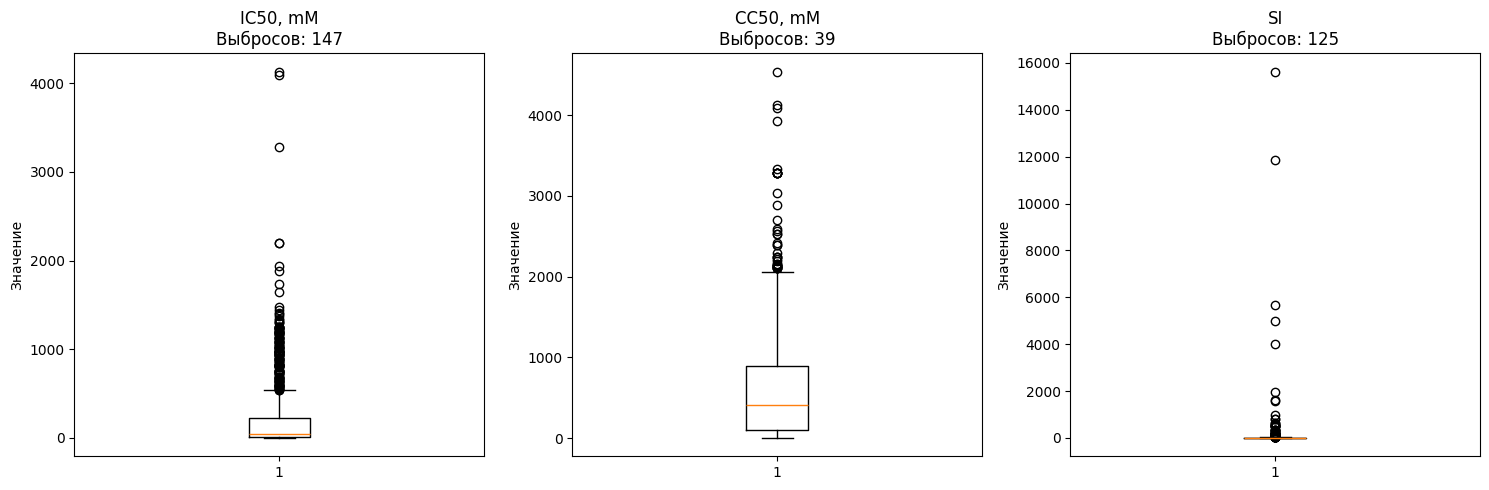

In [ ]:
targets = ['IC50, mM', 'CC50, mM', 'SI']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(targets):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'{col}\nВыбросов: {len(outliers)}')
    axes[i].set_ylabel('Значение')

plt.tight_layout()
plt.show()

Что видно по боксплотам. Первый ящик маленький, значит большинство данных о соединениях находится в диапазоне 0-(~150) миллимоль на литр. Но выбросы есть и они доходят даже до значений около ~4000, помня про отношение из которого рассчитывается SI, про то что чем меньше IC50 тем лучше для итоговой формулы, можно сделать вывод что для части лекарств, нужна огромная концентрация чтобы подавить грипп. По стандартам взяли квартили в 25 и 75 процентов, думаю стоит пересмотреть, тк вряд ли какие то из них действительно с первого взгляда являются классическими в нашем понимании выбросами и их можно удалить, вполне может быть такое что для того чтобы подавить болезнь требуется убойная доза вещества (что плохо).

По токсичности вещества ситуация приятнее (CC50), выбросов меньше, ящик шире медиану хотя бы видно в конце концов в отличии от боксплота Si, но тут еще труднее сказать про потенциальные действительные выбросы.

Боксплот SI полностью прижат к нулю, признак хаотичен по распределению и выявить какую то закономерность трудно. Есть один маркер в значении 16000, какая то панацея, но очевидно что кол-во вещества в знаменателе (грубо имея ввиду что это колличество) стремится к нулю, и SI должен быть большим.

Что касается пропусков, то они одинаковы во первых у одного "семейства" по названию. 4 показывают видимо экстремумы, а остальные имеют общее начало названия BCUT2D (поймем что они значат попозже). Во вторых они все имеют пропуск в 3% примерно. Наверняка это значит какой то сбой в моменте сбора данных, значит можно заполнять способом медианы.

Стоит подвести маленькую черточку, удалять какие то якобы выбросы будет опасной затеей, мы спокойно можем так избавиться от того самого случая который нам нужен, поэтому вместо того чтобы эксперементировать с построением графиков мы применим скорее всего логарифмическое преобразование таргетов. Убедимся что хвосты нужно сжать. На самом деле это понятно уже по боксплотам, по их правому усу, но все равно убедимся лишний раз

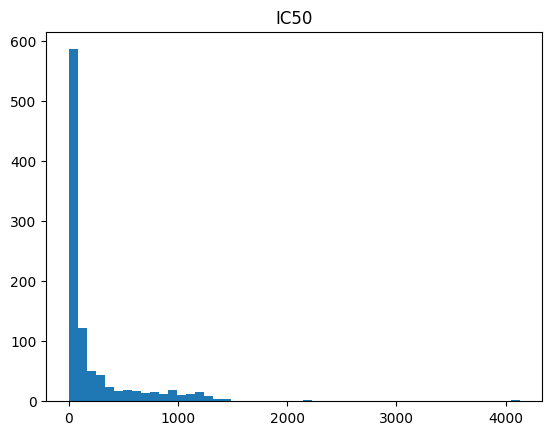

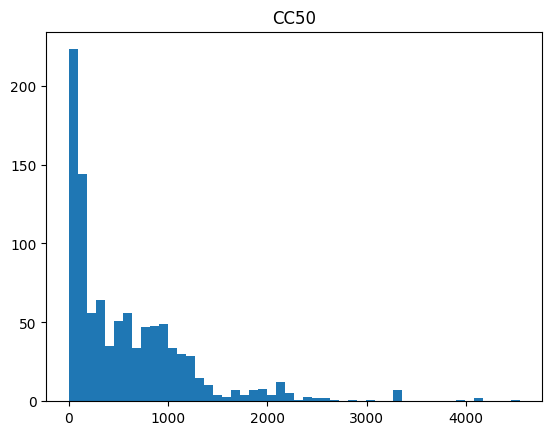

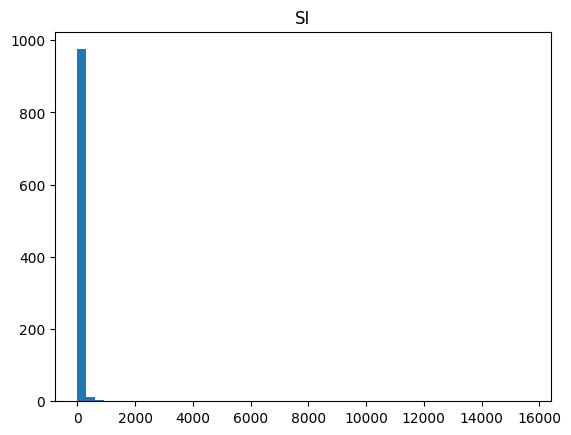

In [ ]:
plt.hist(df['IC50, mM'], bins=50)
plt.title('IC50')
plt.show()

plt.hist(df['CC50, mM'], bins=50)
plt.title('CC50')
plt.show()

plt.hist(df['SI'], bins=50)
plt.title('SI')
plt.show()

Что и требовалось доказать. Будем логарифмировать. Но не бывает же данных без выбросов? Какую то часть все же придется удалять.

Посмотрим строки с отрицательными значениями у таргетов, вдруг есть

In [ ]:
cols = ['IC50, mM', 'CC50, mM', 'SI']
df = df[(df[cols] > 0).all(axis=1)]
df.shape

(1001, 214)

Таковых нет, данные записаны замечательно. Заполним пока медианой пропуски

In [ ]:
cols = [
    'MaxPartialCharge', 'MinPartialCharge',
    'MaxAbsPartialCharge', 'MinAbsPartialCharge',
    'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI',
    'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW',
    'BCUT2D_MRHI', 'BCUT2D_MRLOW'
]

for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

print(df.isnull().sum().sum())

0


Отлично, заполнили

In [ ]:
# сколько потеряем при нестандартных квантилях
quantile_pairs = [
    (0.01, 0.99),
    (0.02, 0.98),
    (0.03, 0.97),
    (0.04, 0.97),
    (0.05, 0.95),
]

for col in targets:
    print(col)
    for q_low, q_high in quantile_pairs:
        low = df[col].quantile(q_low)
        high = df[col].quantile(q_high)
        mask = (df[col] >= low) & (df[col] <= high)
        kept = mask.sum()
        lost = len(df) - kept
        print(f"[{q_low} / {q_high}] удаляем {lost} строк,"
              f"остаётся {kept} ({round(kept/len(df)*100,1)}%)")
    print()

IC50, mM
[0.01 / 0.99] удаляем 20 строк,остаётся 981 (98.0%)
[0.02 / 0.98] удаляем 40 строк,остаётся 961 (96.0%)
[0.03 / 0.97] удаляем 60 строк,остаётся 941 (94.0%)
[0.04 / 0.97] удаляем 70 строк,остаётся 931 (93.0%)
[0.05 / 0.95] удаляем 100 строк,остаётся 901 (90.0%)

CC50, mM
[0.01 / 0.99] удаляем 15 строк,остаётся 986 (98.5%)
[0.02 / 0.98] удаляем 40 строк,остаётся 961 (96.0%)
[0.03 / 0.97] удаляем 60 строк,остаётся 941 (94.0%)
[0.04 / 0.97] удаляем 70 строк,остаётся 931 (93.0%)
[0.05 / 0.95] удаляем 100 строк,остаётся 901 (90.0%)

SI
[0.01 / 0.99] удаляем 20 строк,остаётся 981 (98.0%)
[0.02 / 0.98] удаляем 40 строк,остаётся 961 (96.0%)
[0.03 / 0.97] удаляем 59 строк,остаётся 942 (94.1%)
[0.04 / 0.97] удаляем 70 строк,остаётся 931 (93.0%)
[0.05 / 0.95] удаляем 100 строк,остаётся 901 (90.0%)



UPD: лучшим оказался результат 0.04, 0.97. Его и оставим

Приступим к обработке мультколлинеарности

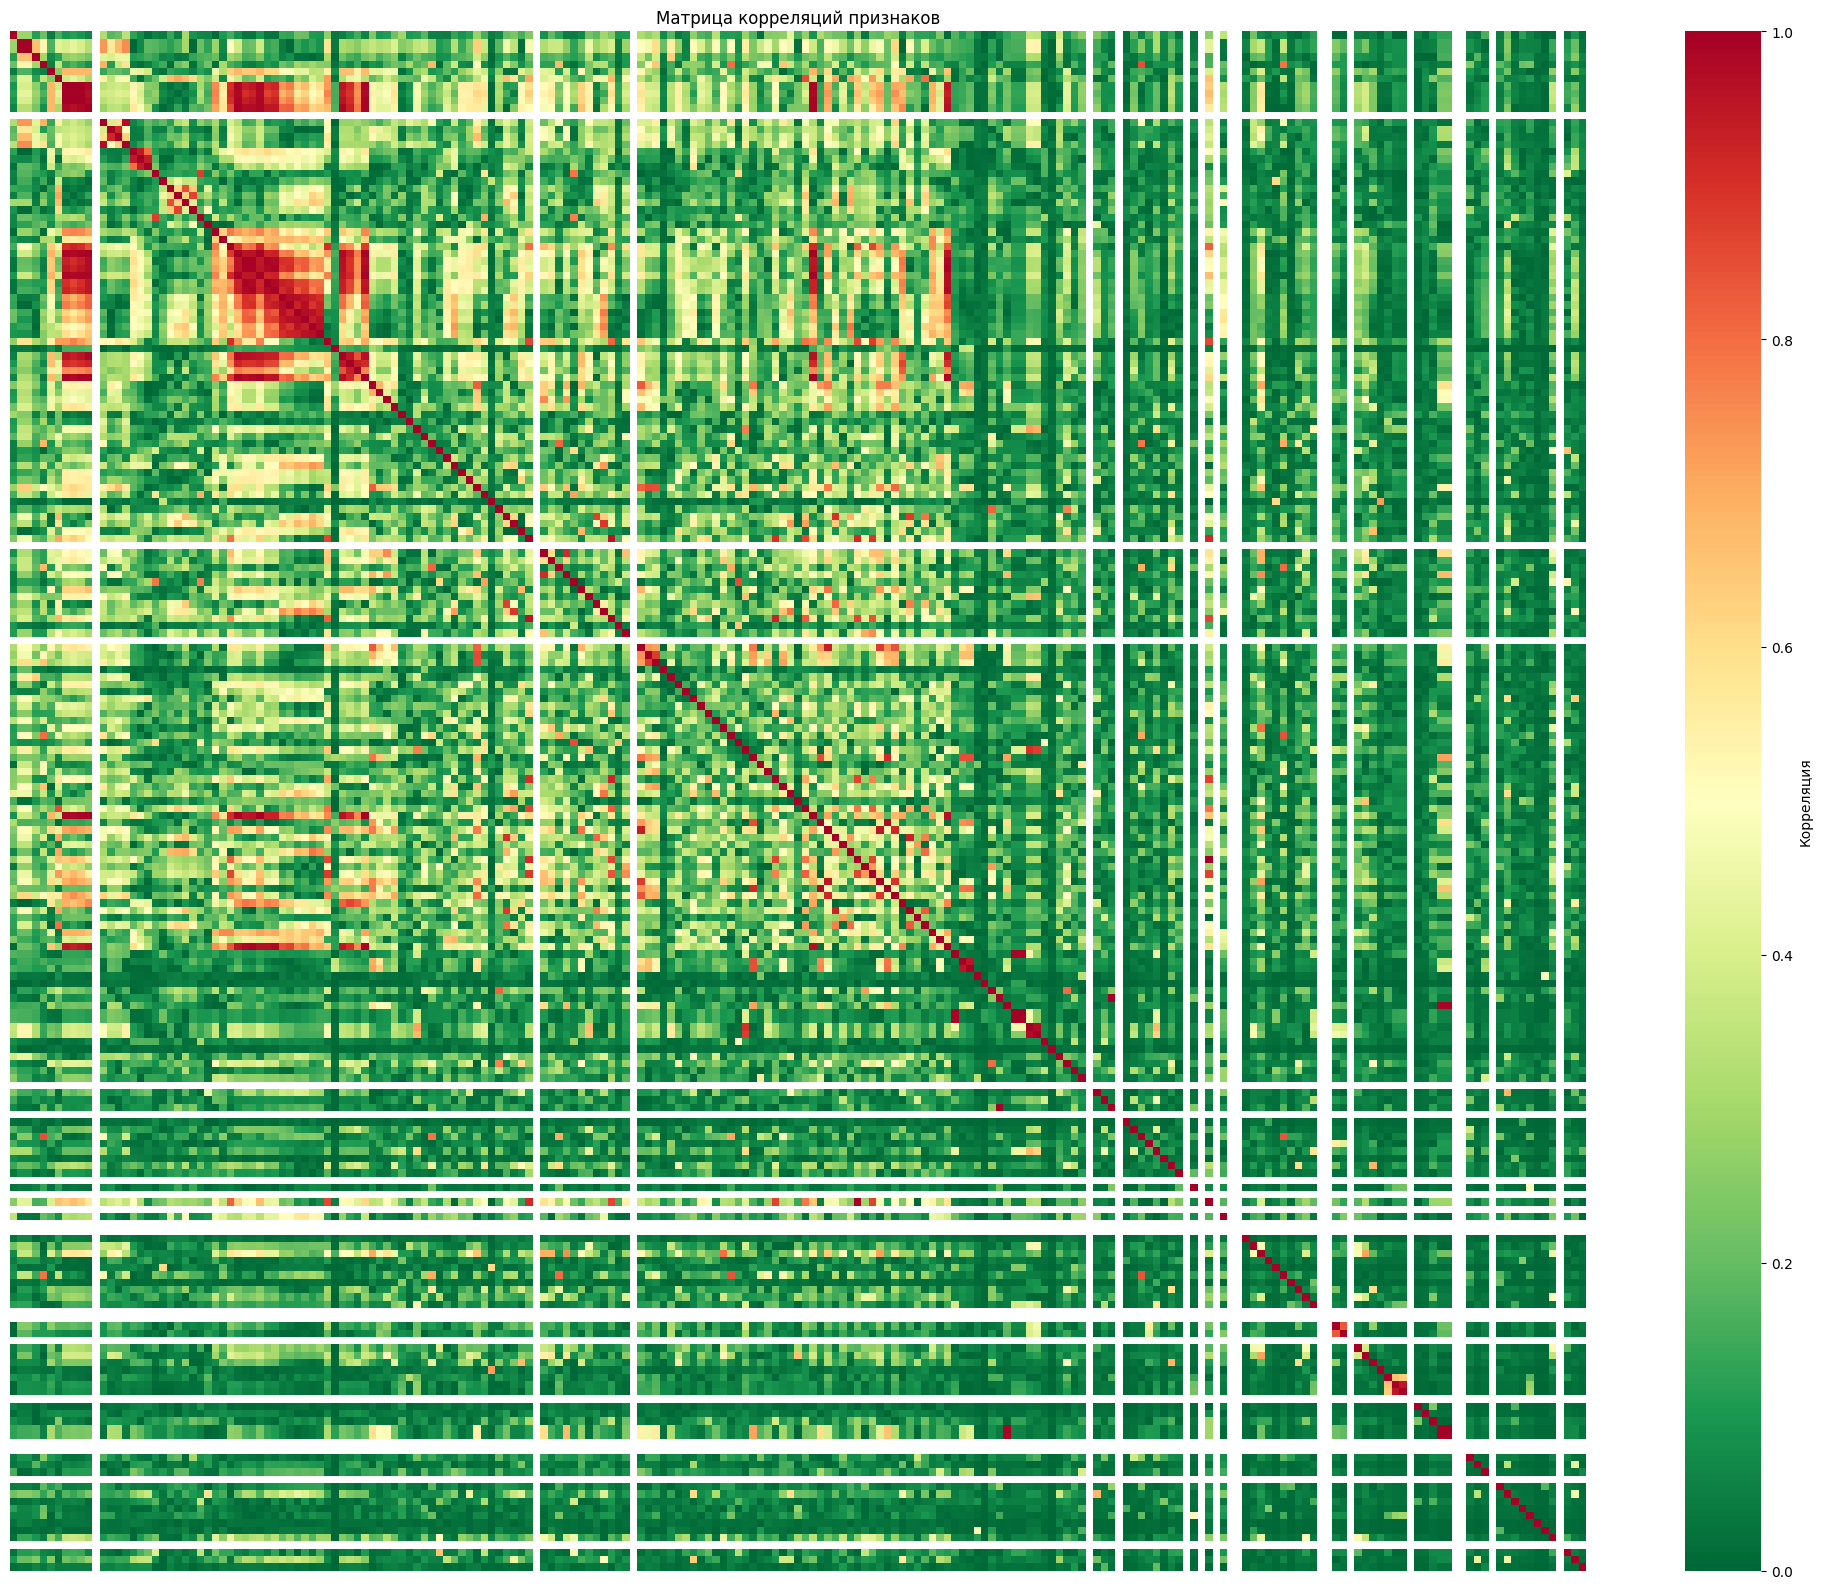

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = df.drop(columns=targets)
corr_matrix = feature_cols.corr(numeric_only=True).abs()

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    cmap='RdYlGn_r',
    vmin=0, vmax=1,
    xticklabels=False,
    yticklabels=False,
    cbar_kws={'label': 'Корреляция'}
)
plt.title('Матрица корреляций признаков')
plt.tight_layout()
plt.show()

UPD:

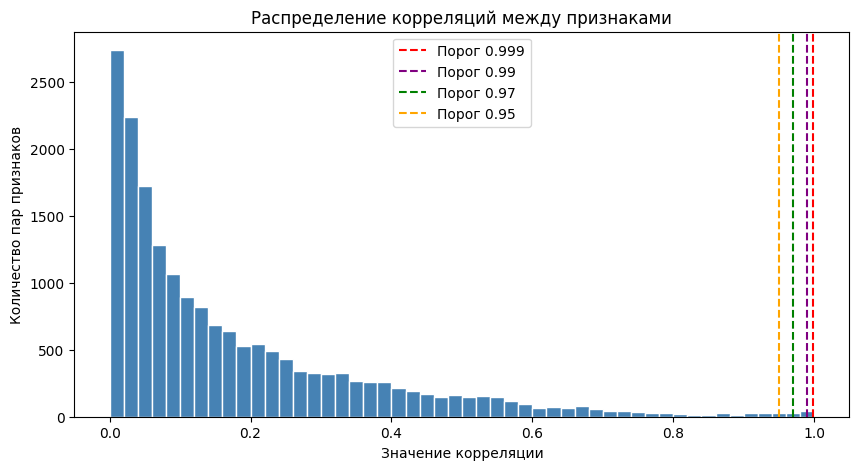

Пар с корреляцией > 0.999: 6
Пар с корреляцией > 0.99:  21
Пар с корреляцией > 0.97:  57
Пар с корреляцией > 0.95:  91


In [ ]:
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
corr_values = upper_triangle.stack()

plt.figure(figsize=(10, 5))

plt.hist(
    corr_values,
    bins=50,
    color='steelblue',
    edgecolor='white'
)

plt.axvline(x=0.999, color='red', linestyle='--', label='Порог 0.999')
plt.axvline(x=0.99, color='purple', linestyle='--', label='Порог 0.99')
plt.axvline(x=0.97, color='green', linestyle='--', label='Порог 0.97')
plt.axvline(x=0.95, color='orange', linestyle='--', label='Порог 0.95')

plt.xlabel('Значение корреляции')
plt.ylabel('Количество пар признаков')
plt.title('Распределение корреляций между признаками')
plt.legend()

plt.show()

print(f"Пар с корреляцией > 0.999: {(corr_values > 0.999).sum()}")
print(f"Пар с корреляцией > 0.99: {(corr_values > 0.99).sum()}")
print(f"Пар с корреляцией > 0.97: {(corr_values > 0.97).sum()}")
print(f"Пар с корреляцией > 0.95: {(corr_values > 0.95).sum()}")

Трудный выбор.
Участки сильной корреляции в левом верхнем углу это взаимосвязь молекулярных дескрипторов между собой. Можно их объединять в один признак или просто оставить и удалить пары корреляций которые выше определенного порога схожести? Нужно порассуждать.

Данных у нас мало, мы должны любым способом сохранить как можно больше с одной стороны. С другой если мы объединим тот красный кластер данных в один например методом главных компонент, то физически по сути смысл пропадает. А смысл/информация максимальна важна. То есть мы можем сейчас захотеть как лучше, а сделаем только хуже если потеряется интерпретируемость.

Думаю нужно поступить так, мы вывели пары корреляций. Признаки с корреляцией выше 0.999 точно дубли. Кстати о дублях мы их не убрали

In [ ]:
print(df.duplicated().sum())
df = df.drop_duplicates()
df.shape

0


(1001, 214)

Дубликатов нет

In [ ]:
feature_cols = df.drop(columns=targets)
corr_matrix = feature_cols.corr(numeric_only=True).abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

redundant_cols = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > 0.999)
]

df.drop(columns=redundant_cols, inplace=True)

print(len(redundant_cols))
df.shape

6


(1001, 208)

In [ ]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df.shape

(990, 207)


Топ-5 признаков для IC50, mM:
VSA_EState4    0.271846
Chi2n          0.260437
PEOE_VSA7      0.258679
Chi2v          0.252982
Chi4v          0.248625
dtype: float64

Топ-5 признаков для CC50, mM:
MolMR             0.312024
LabuteASA         0.310983
MolWt             0.307920
HeavyAtomCount    0.306917
Chi1              0.306136
dtype: float64

Топ-5 признаков для SI:
BCUT2D_MWLOW    0.245290
SMR_VSA7        0.181111
fr_sulfonamd    0.179018
FractionCSP3    0.172738
RingCount       0.169429
dtype: float64


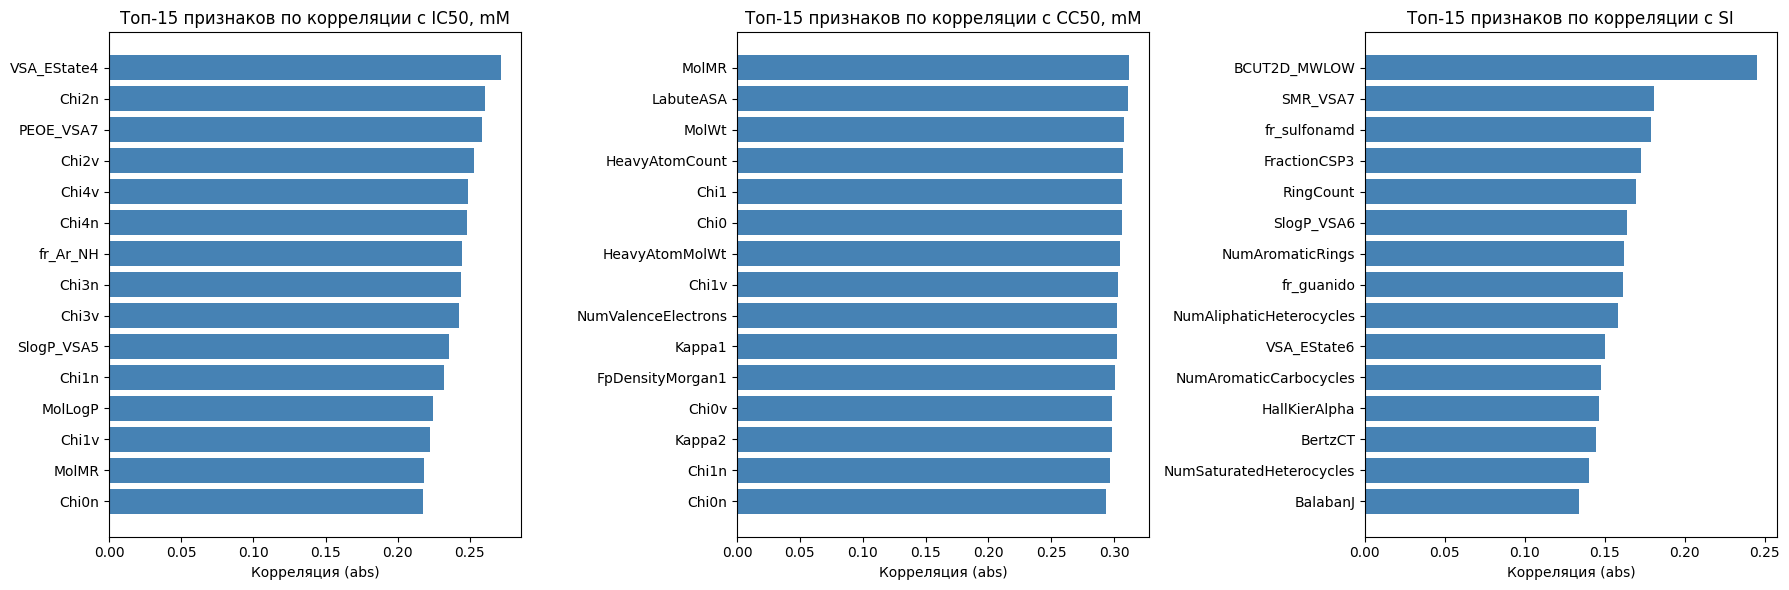

In [ ]:
feature_cols = df.drop(columns=targets)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, target in enumerate(targets):
    corr_with_target = feature_cols.corrwith(df[target]).abs().sort_values(ascending=False)
    top15 = corr_with_target.head(15)

    axes[i].barh(top15.index[::-1], top15.values[::-1], color='steelblue')
    axes[i].set_title(f'Топ-15 признаков по корреляции с {target}')
    axes[i].set_xlabel('Корреляция (abs)')

    print(f"\nТоп-5 признаков для {target}:")
    print(top15.head())

plt.tight_layout()
plt.show()

Линейные слабые, по всем трем таргетам

In [ ]:
def filter_extreme_values(data, columns, multiplier=3):
    result = data.copy()

    for feature in columns:
        p40 = result[feature].quantile(0.4)
        p97 = result[feature].quantile(0.97)
        spread = p97 - p40

        ceiling = p97 + multiplier * spread
        result = result[result[feature] <= ceiling]

    return result

target_cols = ['IC50, mM', 'CC50, mM', 'SI', 'MolWt', 'MolLogP', 'TPSA']

before = len(df)
df = filter_extreme_values(df, target_cols)
df = df.reset_index(drop=True)

print(before)
print(len(df))
print(before - len(df))

Строк до очистки: 1001
Строк после очистки: 990
Удалено: 11


In [ ]:
ic50_median = df['IC50, mM'].median()
cc50_median = df['CC50, mM'].median()
si_median = df['SI'].median()
print(ic50_median)
print(cc50_median)
print(si_median)

df['IC50_above_median'] = (df['IC50, mM'] > ic50_median).astype(int)
df['CC50_above_median'] = (df['CC50, mM'] > cc50_median).astype(int)
df['SI_above_median']   = (df['SI'] > si_median).astype(int)
df['SI_above_8']        = (df['SI'] > 8).astype(int)

for col in ['IC50_above_median', 'CC50_above_median', 'SI_above_median', 'SI_above_8']:
    counts = df[col].value_counts()
    ratio = round(counts[1] / len(df) * 100, 1)
    print(f"{col}: 1 {counts[1]} ({ratio}%), 0 {counts[0]} ({100-ratio}%)")

48.75453432657268
419.7702759089003
3.6693186454508364
IC50_above_median: 1 495 (50.0%), 0 495 (50.0%)
CC50_above_median: 1 495 (50.0%), 0 495 (50.0%)
SI_above_median: 1 495 (50.0%), 0 495 (50.0%)
SI_above_8: 1 346 (34.9%), 0 644 (65.1%)


In [ ]:
df.shape

(990, 211)

#Вывод по EDA

Медиана поделила выборку пополам, IC50 = 48.75. У 50 процентов соединений концентрация достаточная для подавления гриппа, то есть меньше 48.75 миллимоль на литр. CC50 = 419.77, у половины токсичность для клеток настает только при высокой концентрации, все корреляции признаков с таргетами слабоватые, линейность почти отсутсвует. Линейные модели покажут слабые результаты, ставим на ансамблевые методы.

SI > 8 дал дисбаланс 35% против 65% т.е. только треть соединений проходит порог безопасности, accuracy не подойдет

Так же итого мы имеем 990 строк и 211 признаков (добавили медианы для классификаций).

In [ ]:
df.to_pickle("dataset_after_eda.pkl")